<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana10/MediaMovil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/ MetodosComputacionales2026")

In [41]:
import pandas as pd
data = pd.read_csv('Semana10/Data/MediaMovilData.csv')
x = np.array(data)

In [42]:
import numpy as np
import matplotlib.pyplot as plt

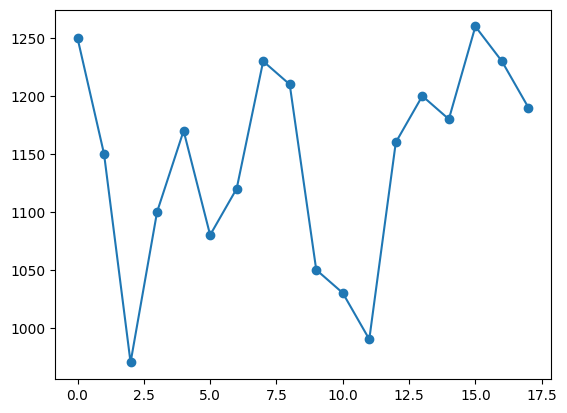

In [43]:
plt.plot(x, '-o')

In [44]:
mean = np.mean(x)
mean

np.float64(1142.7777777777778)

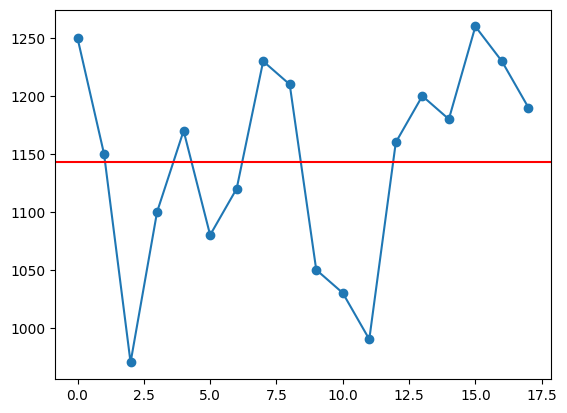

In [45]:
plt.plot(x, '-o')
plt.axhline(mean, color='r')

In [52]:
x

array([[1250],
       [1150],
       [ 970],
       [1100],
       [1170],
       [1080],
       [1120],
       [1230],
       [1210],
       [1050],
       [1030],
       [ 990],
       [1160],
       [1200],
       [1180],
       [1260],
       [1230],
       [1190]])

In [47]:
# Hagamos un modelo de media movil
def GetMediaMovil(x,n):

  media = np.zeros(len(x)+1)

  for i in range(len(media)):

    sum_ = 0.

    if i >= n:

      for j in range(i-n,i):

        sum_ += x[j]

      media[i] = sum_/n

    else:
      media[i] = x[i]

  return media


In [66]:
# n dias es un hiperparametro del modelo
media = GetMediaMovil(x,3)

/tmp/ipykernel_43283/3337237661.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  media[i] = x[i]
/tmp/ipykernel_43283/3337237661.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  media[i] = sum_/n


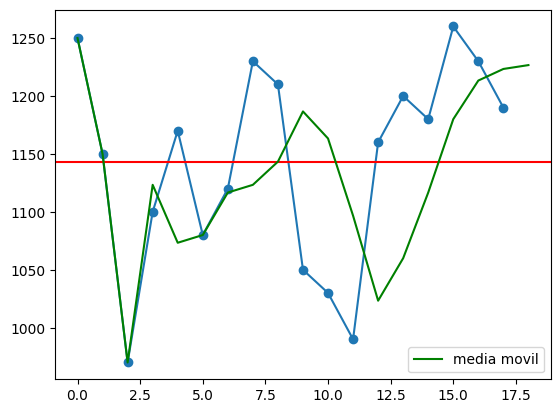

In [67]:
plt.plot(x, '-o')
plt.axhline(mean, color='r')
plt.plot(media,'g',label='media movil')
plt.legend()

In [68]:
# Necesiamos una "metrica" un numero
# un modelo pesado
def GetWeightedMediaMovil(x,w):

  n = len(w)

  media = np.zeros(len(x)+1)

  for i in range(len(media)):

    sum_ = 0.

    if i >= n:

      k = 0
      for j in range(i-n,i):

        sum_ += w[k]*x[j]
        k += 1

      media[i] = sum_

    else:
      media[i] = x[i]

  return media

In [71]:
w = np.array([0.6,0.2,0.2])
wmedia = GetWeightedMediaMovil(x,w)

/tmp/ipykernel_43283/1120123158.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  media[i] = x[i]
/tmp/ipykernel_43283/1120123158.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  media[i] = sum_


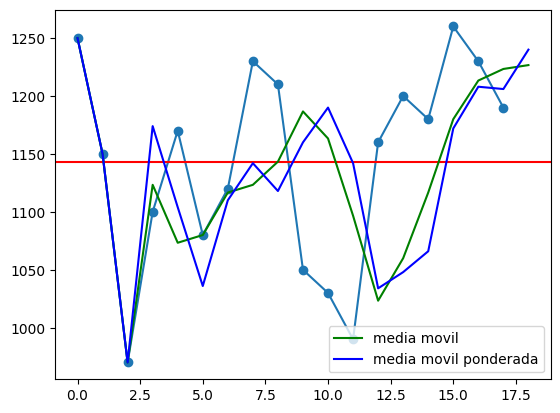

In [72]:
plt.plot(x, '-o')
plt.axhline(mean, color='r')
plt.plot(media,'g',label='media movil')
plt.plot(wmedia,'b',label='media movil ponderada')
plt.legend()